# Objectif du notebook 

Date de création : 20/012026

L'objectif est de d'estimer / d'étudier le décalage de la base temporelle de l'hydrophone source et des OBS. 

Les temps d'arrivée des signaux sont estimés par filtrage adapté des chirps (80 Hz - 1 kHz). 

In [1]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import soundfile as sf
import matplotlib.pyplot as plt

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

In [3]:
sys.path.append(project_root)
from publication.publication_figure import PubFigure, color
from real_data_analysis.fiberscope_groix.src.data_processing.arrivals_utils import *

In [4]:
pfig = PubFigure(
    label_fontsize=18, legend_fontsize=10, ticks_fontsize=16, title_fontsize=20
)

# Chargement des données utiles 

In [5]:
# Load GPS dataset for station coordinates
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))

# Load arrivals dataset
fpath = os.path.join(
    data_folder,
    f"processed_arrivals.nc",
)
ds_arr = xr.open_dataset(fpath)
df_arr = ds_arr.to_dataframe()

# Estimation du décalage des deux bases de temps UTC 

Le temps UTC de l'hydro source, utilisé pour pointer les temps d'émission, n'est pas parfaitement synchronisé avec le temps UTC GPS (celui des OBS). L'objectif est d'exploiter les émissions au-dessus de chacun des OBSs afin d'estimer ce décalage. 

Cette étape préalable est nécessaire pour la suite de l'estimation des temps d'arrivée. En effet certaine des émissions ne sont pas détectées, dans ce cas, il faut associer les arrivées éparses détectées aux émissions correspondantes. L'alignement des deux bases de temps est nécessaire à cette étape permettant de renforcer la robustesse de la méthode. 

## Détails

* Les temps d'arrivées théoriques sont donnés en temps UTC de l'hydrophone : $t_{th_{arr}}^{(Hydro)}$
* Les temps d'arrivées mesurés sont donnés en temps UTC de l'OBS : $t_{arr}^{(OBS)}$

Le shift entre les deux bases de temps est donné (aux erreurs de mesures et de modélisation près) par : 
$$ \tau_{Hydro} = t_{th_{arr}}^{(Hydro)} - t_{arr}^{(OBS)}$$

Ici le shift est évalué sur la différence de temps de propagation : 

* Le temps de propagation théorique est donné par : 
$$\tau_{th} = t_{th_{arr}}^{(Hydro)} - t_{emission}^{(Hydro)}$$ 
* Le temps de propagation mesuré est donné par :
$$\tau_{mes} = t_{arr}^{(OBS)} - t_{emission}^{(Hydro)}$$

et on a donc : 

$$\tau_{Hydro} = \tau_{th} - \tau_{mes} $$

## Définition des séquences d'émission à utiliser pour le calcul du shift 

Les séquences retenues sont les séquences les plus favorables à la détection des temps d’arrivée. Au total 27 séquences correspondant aux chirps à 4 V, 2 V ou 1 V, pour lesquelles les 10 émissions successives de la séquence sont détectés sur les trois OBS.


In [6]:
# VC = 4V
sel_seq_id_4v = [
    12,
    24,
    35,
    39,
    51,
    80,
    90,
    116,
    127,
    131,
    143,
    151,
    155,
    167,
]  # Séquence correstement détectées pour VC = 4V (inspection visuelle)

# VC = 2V
sel_seq_id_2v = [13, 25, 40, 81, 117, 132, 156]

# VC = 1V
sel_seq_id_1v = [14, 26, 41, 118, 133, 157]

sel_sequence_id = sel_seq_id_2v + sel_seq_id_4v + sel_seq_id_1v

print(f"Sequences 4V : {len(sel_seq_id_4v)}")
print(f"Sequences 2V : {len(sel_seq_id_2v)}")
print(f"Sequences 1V : {len(sel_seq_id_1v)}")

Sequences 4V : 14
Sequences 2V : 7
Sequences 1V : 6


In [7]:
# Select only the desired sequences
df_processed = df_arr[df_arr["sequence_id"].isin(sel_sequence_id)]

## Calcul du décalage observé

In [8]:
# Estimation du décalage temporel entre les deux bases de temps
time_diff = {}
sel_sequence_id = df_processed["sequence_id"].unique()
for i, seq_id in enumerate(sel_sequence_id):
    df_sequence = df_processed.loc[df_processed["sequence_id"] == seq_id]
    time_diff[seq_id] = {}
    # Store emission datetime
    time_diff[seq_id]["first_emission_datetime"] = (
        df_sequence["emission_datetime"].iloc[0].to_pydatetime(warn=False)
    )

    print(f"Sequence {seq_id} - Emission on OBS{i%3+1}") 

    for obs_id in [1, 2, 3]:

        # Store first position
        time_diff[seq_id][f"theoretical_propagation_time_obs{obs_id}"] = df_sequence[
            f"theoretical_propagation_time_obs{obs_id}"
        ].iloc[0]

        print(f"OBS{obs_id}:")
        # print(f'\tEmissions: {df_sequence["Emission datetime"]}')
        print(
            f'\tTheoretical propagation time (mean) : {np.mean(df_sequence[f"theoretical_propagation_time_obs{obs_id}"])} s'
        )
        print(
            f'\tPropagation dist (mean th propa time): {np.mean(df_sequence[f"theoretical_propagation_time_obs{obs_id}"]) * 1500} m'
        )
        print(
            f'\tMeasured propagation time (mean) : {np.mean(df_sequence[f"measured_propagation_time_obs{obs_id}"])} s'
        )
        print(
            f'\tPropagation dist (mean meas propa time): {np.mean(df_sequence[f"measured_propagation_time_obs{obs_id}"]) * 1500} m'
        )

        time_diffs = (
            df_sequence[f"theoretical_propagation_time_obs{obs_id}"]
            - df_sequence[f"measured_propagation_time_obs{obs_id}"]
        )
        # print(time_diffs)
        time_offset_median = np.nanmedian(time_diffs)
        time_offset_mean = np.nanmean(time_diffs)
        time_offset_std = np.nanstd(time_diffs)
        # print(f"Estimated time offset for OBS{obs_id}: {time_offset} s")
        print(
            f"\tEstimated time offset: \n\t\tmedian={time_offset_median:.3f} s \n\t\tmean={time_offset_mean:.3f} s \n\t\tstd={time_offset_std:.3f} s"
        )

        # Store
        time_diff[seq_id][f"OBS{obs_id}"] = {
            "median": time_offset_median,
            "mean": time_offset_mean,
            "std": time_offset_std,
        }


print(time_diff)

Sequence 12 - Emission on OBS1
OBS1:
	Theoretical propagation time (mean) : 0.023142229930601853 s
	Propagation dist (mean th propa time): 34.71334489590278 m
	Measured propagation time (mean) : 0.31598499999999996 s
	Propagation dist (mean meas propa time): 473.97749999999996 m
	Estimated time offset: 
		median=-0.294 s 
		mean=-0.293 s 
		std=0.002 s
OBS2:
	Theoretical propagation time (mean) : 0.5973811435689318 s
	Propagation dist (mean th propa time): 896.0717153533977 m
	Measured propagation time (mean) : 0.8869850000000001 s
	Propagation dist (mean meas propa time): 1330.4775000000002 m
	Estimated time offset: 
		median=-0.290 s 
		mean=-0.290 s 
		std=0.003 s
OBS3:
	Theoretical propagation time (mean) : 1.22807304914468 s
	Propagation dist (mean th propa time): 1842.10957371702 m
	Measured propagation time (mean) : 1.511285 s
	Propagation dist (mean meas propa time): 2266.9275 m
	Estimated time offset: 
		median=-0.280 s 
		mean=-0.283 s 
		std=0.007 s
Sequence 13 - Emission on

### Commentaires 

* Pour une séquence d’émission donnée, le décalage est identique sur les trois OBS, avec des variations entre OBS de l’ordre du centième de seconde.

* Le shift mesuré varie en revanche significativement selon la séquence considérée, de l’ordre de plus d’une seconde.

Le décalage entre les deux bases de temps est estimé à partir de la différence entre le temps de propagation théorique et le temps de propagation mesuré. Le temps de propagation théorique est connu, aux erreurs de positionnement près de la source et des OBS (avec c = 1500 m/s). Avec une erreur d’un centième de seconde sur les temps de propagation théoriques, on est à environ 15 m, ce qui correspond au bon ordre de grandeur pour l’erreur de positionnement.

In [9]:
# Plot time differences for each sequence and each OBS
pfig = PubFigure(
    label_fontsize=18, legend_fontsize=10, ticks_fontsize=16, title_fontsize=20
)
sequence_datetimes = [time_diff[seq_id]["first_emission_datetime"] for seq_id in sel_sequence_id]
obs1_mean_time_offsets = [time_diff[seq_id]["OBS1"]["mean"] for seq_id in sel_sequence_id]
obs2_mean_time_offsets = [time_diff[seq_id]["OBS2"]["mean"] for seq_id in sel_sequence_id]
obs3_mean_time_offsets = [time_diff[seq_id]["OBS3"]["mean"] for seq_id in sel_sequence_id]
obs1_std_time_offsets = [time_diff[seq_id]["OBS1"]["std"] for seq_id in sel_sequence_id]
obs2_std_time_offsets = [time_diff[seq_id]["OBS2"]["std"] for seq_id in sel_sequence_id]
obs3_std_time_offsets = [time_diff[seq_id]["OBS3"]["std"] for seq_id in sel_sequence_id]

# Sort all data by sequence datetime
ordered_indices = np.argsort(sequence_datetimes)
sequence_datetimes = np.array(sequence_datetimes)[ordered_indices]
obs1_mean_time_offsets = np.array(obs1_mean_time_offsets)[ordered_indices]
obs2_mean_time_offsets = np.array(obs2_mean_time_offsets)[ordered_indices]
obs3_mean_time_offsets = np.array(obs3_mean_time_offsets)[ordered_indices]
obs1_std_time_offsets = np.array(obs1_std_time_offsets)[ordered_indices]
obs2_std_time_offsets = np.array(obs2_std_time_offsets)[ordered_indices]
obs3_std_time_offsets = np.array(obs3_std_time_offsets)[ordered_indices]



# Analyse des variations du shift mesuré

## Variations du shift en fonction du temps 

In [10]:
days = np.unique([d.date() for d in sequence_datetimes])

### Évolution journalière

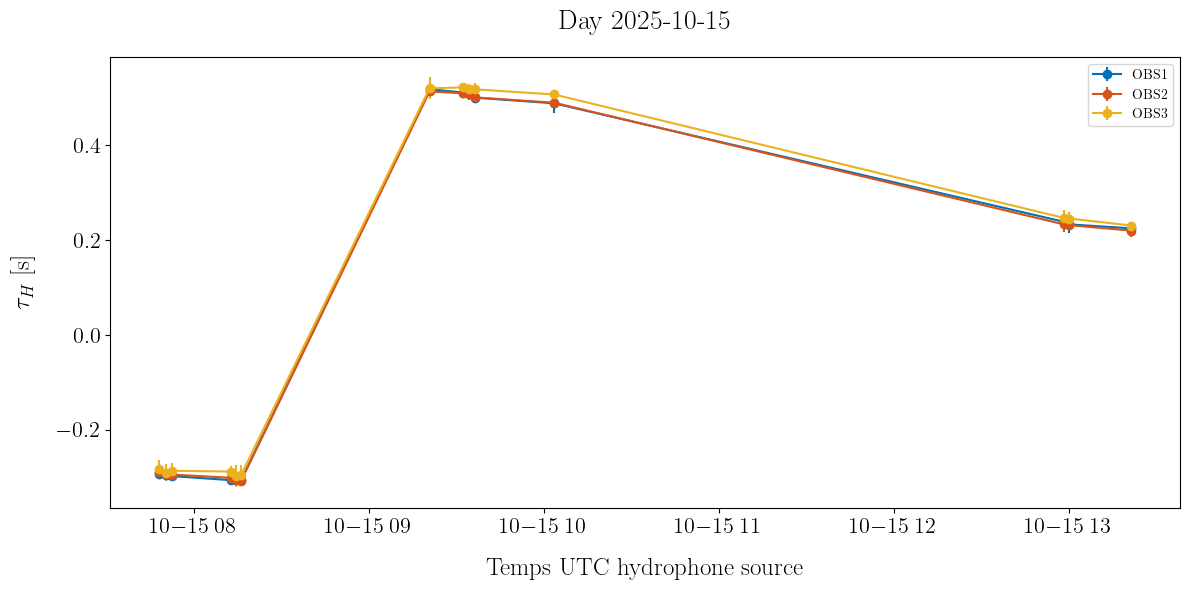

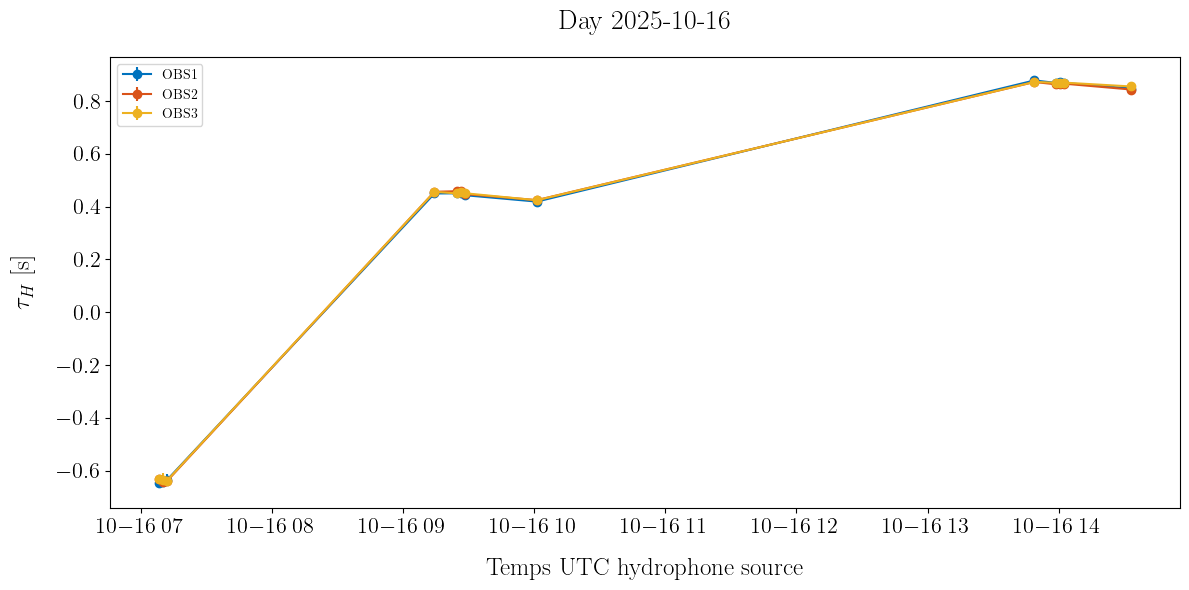

In [11]:
for day_idx, day in enumerate(days):
    # ax = axs[day_idx] if days.size > 1 else axs
    plt.figure(figsize=(12, 6))
    ax = plt.gca()
    day_mask = np.array([d.date() == day for d in sequence_datetimes])
    ax.errorbar(
        np.array(sequence_datetimes)[day_mask],
        np.array(obs1_mean_time_offsets)[day_mask],
        yerr=3 * np.array(obs1_std_time_offsets)[day_mask],
        fmt="o-",
        label="OBS1",
        color=color(0),
    )
    ax.errorbar(
        np.array(sequence_datetimes)[day_mask],
        np.array(obs2_mean_time_offsets)[day_mask],
        yerr=3 * np.array(obs2_std_time_offsets)[day_mask],
        fmt="o-",
        label="OBS2",
        color=color(1),
    )
    ax.errorbar(
        np.array(sequence_datetimes)[day_mask],
        np.array(obs3_mean_time_offsets)[day_mask],
        yerr=3 * np.array(obs3_std_time_offsets)[day_mask],
        fmt="o-",
        label="OBS3",
        color=color(2),
    )
    ax.set_title(f"Day {day}")
    ax.set_xlabel("Temps UTC hydrophone source")
    ax.set_ylabel(r"$\tau_{H}$ [s]")
    ax.legend()

#### Commentaires 

Le shift ne varie clairement pas de manière aléatoire en fonction du temps (ce qu’on aurait a priori observé dans le cas d’erreurs d’estimation résultant uniquement des incertitudes de positionnement), mais croît de façon quasi linéaire par morceaux.

Hypothèse : le shift observé correspond à une dérive de l’horloge de l’enregistreur de l’hydrophone source, dérive qui pourrait être réinitialisée lors de la mise en route de l'enregistreur. 

### Évolution par morceaux

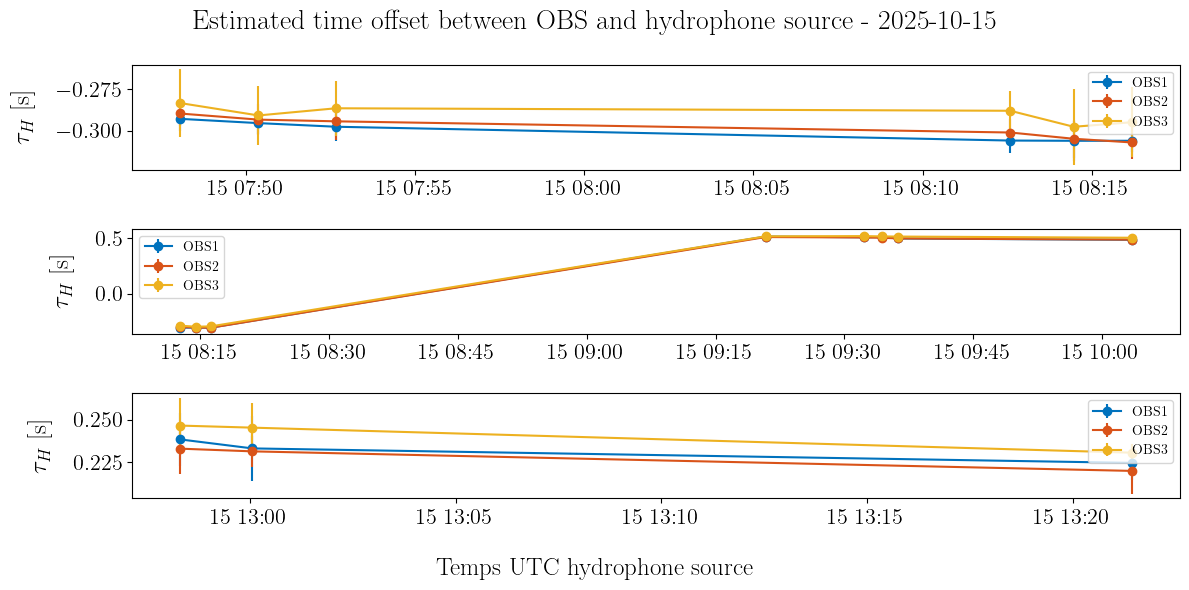

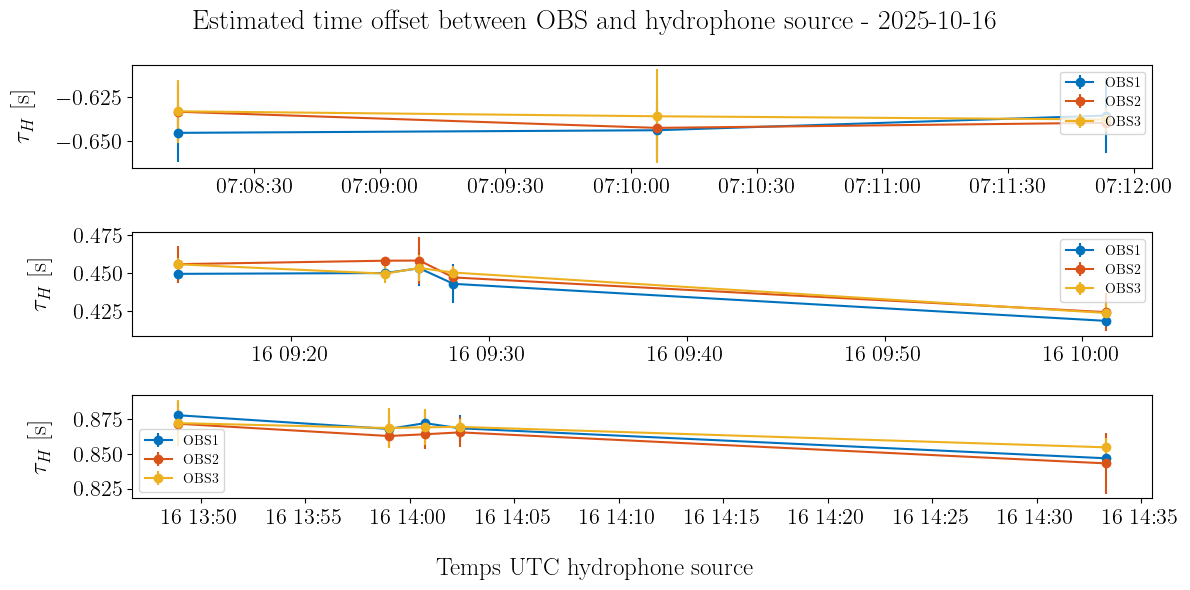

In [12]:
hour_lim_1 = 8
hour_lim_2 = 11

for day_idx, day in enumerate(days):
    # plt.figure(figsize=(12, 6))
    # ax = plt.gca()

    # ax = axs[day_idx] if days.size > 1 else axs
    fig, axs = plt.subplots(3, 1, figsize=(12, 6))

    day_mask = np.array([d.date() == day for d in sequence_datetimes])
    hour_lim_1_mask = np.array(
        [d.hour <= hour_lim_1 for d in sequence_datetimes[day_mask]]
    )
    hour_lim_2_mask = np.array(
        [
            (d.hour >= hour_lim_1) and (d.hour <= hour_lim_2)
            for d in sequence_datetimes[day_mask]
        ]
    )
    hour_lim_3_mask = np.array(
        [d.hour > hour_lim_2 for d in sequence_datetimes[day_mask]]
    )

    hour_masks = [hour_lim_1_mask, hour_lim_2_mask, hour_lim_3_mask]
    for i in range(3):
        axs[i].errorbar(
            np.array(sequence_datetimes)[day_mask][hour_masks[i]],
            np.array(obs1_mean_time_offsets)[day_mask][hour_masks[i]],
            yerr=3 * np.array(obs1_std_time_offsets)[day_mask][hour_masks[i]],
            fmt="o-",
            label="OBS1",
            color=color(0),
        )

        axs[i].errorbar(
            np.array(sequence_datetimes)[day_mask][hour_masks[i]],
            np.array(obs2_mean_time_offsets)[day_mask][hour_masks[i]],
            yerr=3 * np.array(obs2_std_time_offsets)[day_mask][hour_masks[i]],
            fmt="o-",
            label="OBS2",
            color=color(1),
        )

        axs[i].errorbar(
            np.array(sequence_datetimes)[day_mask][hour_masks[i]],
            np.array(obs3_mean_time_offsets)[day_mask][hour_masks[i]],
            yerr=3 * np.array(obs3_std_time_offsets)[day_mask][hour_masks[i]],
            fmt="o-",
            label="OBS3",
            color=color(2),
        )

        # axs[i].set_xlabel("Temps UTC hydrophone source")
        axs[i].set_ylabel(r"$\tau_{H}$ [s]")
        axs[i].legend()

    fig.supxlabel("Temps UTC hydrophone source")
    fig.suptitle(f"Estimated time offset between OBS and hydrophone source - {day}")

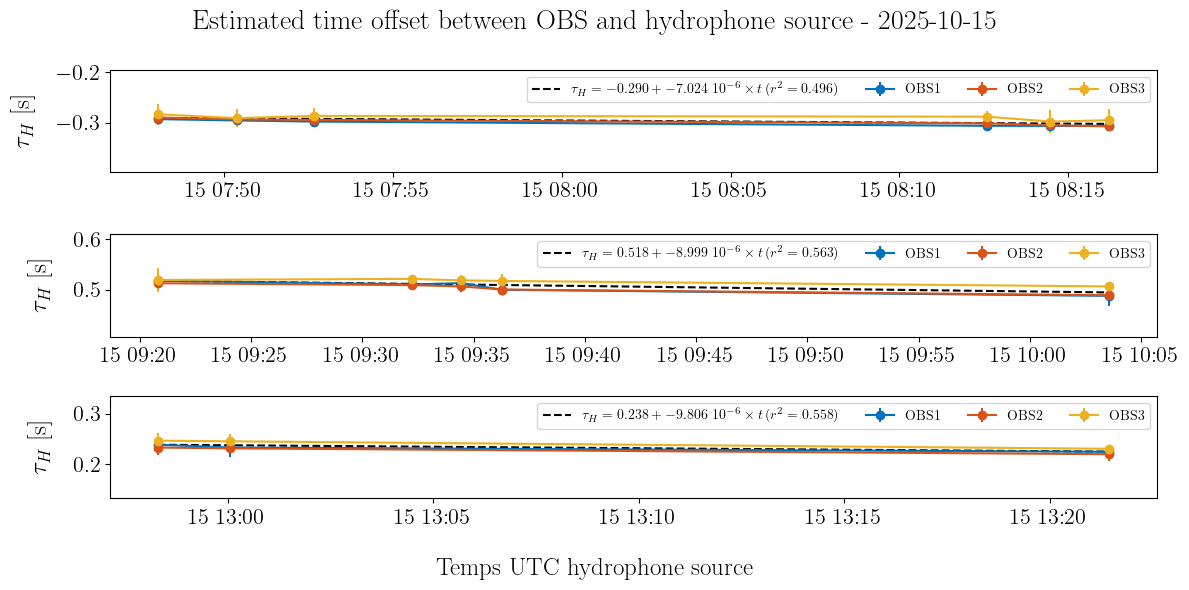

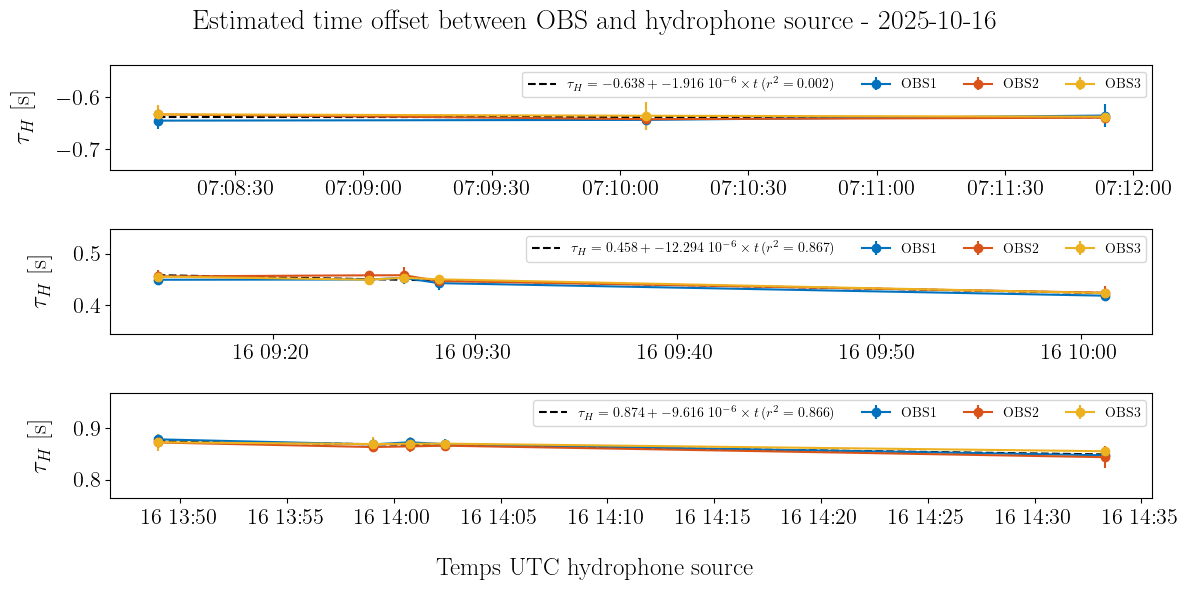

In [13]:
hour_lim_1 = 8.5
hour_lim_2 = 11 

for day_idx, day in enumerate(days):
    # plt.figure(figsize=(12, 6))
    # ax = plt.gca()


    # ax = axs[day_idx] if days.size > 1 else axs
    fig, axs = plt.subplots(
        3, 1, figsize=(12, 6)
    )

    day_mask = np.array([d.date() == day for d in sequence_datetimes])
    hour_lim_1_mask = np.array([d.hour <= hour_lim_1 for d in sequence_datetimes[day_mask]])
    hour_lim_2_mask = np.array(
        [
            (d.hour >= hour_lim_1) and (d.hour <= hour_lim_2)
            for d in sequence_datetimes[day_mask]
        ]
    )
    hour_lim_3_mask = np.array([d.hour > hour_lim_2 for d in sequence_datetimes[day_mask]])

    all_obs = np.hstack([obs1_mean_time_offsets, obs2_mean_time_offsets, obs3_mean_time_offsets])
    ax_min = np.min(all_obs)
    ax_max = np.max(all_obs)
    ax_range = ax_max - ax_min

    hour_masks = [hour_lim_1_mask, hour_lim_2_mask, hour_lim_3_mask]
    for i in range(3):
        time = np.array(sequence_datetimes)[day_mask][hour_masks[i]]
        obs1_masked = np.array(obs1_mean_time_offsets)[day_mask][hour_masks[i]]
        obs2_masked = np.array(obs2_mean_time_offsets)[day_mask][hour_masks[i]]
        obs3_masked = np.array(obs3_mean_time_offsets)[day_mask][hour_masks[i]]

        linear_time = time - time[0] # Linear time from start
        linear_time = [t.total_seconds() for t in linear_time]

        # 
        from scipy.stats import linregress 
        all_obs_masked = np.hstack([obs1_masked, obs2_masked, obs3_masked])
        all_linear_time = np.hstack([linear_time, linear_time, linear_time])
        slope, intercept, r, p, se = linregress(all_linear_time, all_obs_masked)

        # reg_time = np.array([time[0], time[-1]])
        reg_time = pd.date_range(time[0], time[-1], periods=100)
        lin_reg_time = np.array([t.total_seconds() for t in reg_time - reg_time[0]])
        y = intercept + slope * lin_reg_time
        axs[i].errorbar(
            time,
            obs1_masked,
            yerr=3*np.array(obs1_std_time_offsets)[day_mask][hour_masks[i]],
            fmt="o-",
            label="OBS1",
            color=color(0),
        )

        axs[i].errorbar(
            time,
            obs2_masked,
            yerr=3*np.array(obs2_std_time_offsets)[day_mask][hour_masks[i]],
            fmt="o-",
            label="OBS2",
            color=color(1),
        )

        axs[i].errorbar(
            time,
            obs3_masked,
            yerr=3*np.array(obs3_std_time_offsets)[day_mask][hour_masks[i]],
            fmt="o-",
            label="OBS3",
            color=color(2),
        )

        axs[i].plot(reg_time,
                    y,
                    linestyle="--",
                    color="k",
                    label=fr"$\tau_{{H}} = {{{intercept:.3f}}} + {{{slope*1e6:.3f}}}~10^{{-6}} \times t \,(r^2 = {{{r**2:.3f}}})$"
                    )

        # axs[i].set_xlabel("Temps UTC hydrophone source")
        axs[i].set_ylabel(r"$\tau_{H}$ [s]")
        axs[i].legend(ncols=4, loc="upper right")
        axs[i].set_ylim(np.mean(all_obs_masked)-ax_range/15, np.mean(all_obs_masked)+ax_range/15)

    fig.supxlabel("Temps UTC hydrophone source")
    fig.suptitle(f"Estimated time offset between OBS and hydrophone source - {day}")

#### Commentairs 

Variations linéaires du décalage temporel mesuré avec un coefficient de détermination $r^2$ relativement élevé pour des estimations faites sur une période suffisamment longue. 

## Variations en fonction de la distance au capteur 

In [14]:
obs1_th_propagation_times = [
    time_diff[seq_id]["theoretical_propagation_time_obs1"] for seq_id in sel_sequence_id
]
obs2_th_propagation_times = [
    time_diff[seq_id]["theoretical_propagation_time_obs2"] for seq_id in sel_sequence_id
]
obs3_th_propagation_times = [
    time_diff[seq_id]["theoretical_propagation_time_obs3"] for seq_id in sel_sequence_id
]

# Sort data by propagation time
sequence_datetimes = [time_diff[seq_id]["first_emission_datetime"] for seq_id in sel_sequence_id]
sequence_datetimes_obs1 = np.array(sequence_datetimes)[np.argsort(obs1_th_propagation_times)]
sequence_datetimes_obs2 = np.array(sequence_datetimes)[np.argsort(obs2_th_propagation_times)]
sequence_datetimes_obs3 = np.array(sequence_datetimes)[np.argsort(obs3_th_propagation_times)]
sel_sequence_id_obs1 = sel_sequence_id.copy()[np.argsort(obs1_th_propagation_times)
]
sel_sequence_id_obs2 = sel_sequence_id.copy()[np.argsort(obs2_th_propagation_times)
]
sel_sequence_id_obs3 = sel_sequence_id.copy()[np.argsort(obs3_th_propagation_times)
]
obs1_th_propagation_times = np.array(obs1_th_propagation_times)[
    np.argsort(obs1_th_propagation_times)
]
obs2_th_propagation_times = np.array(obs2_th_propagation_times)[
    np.argsort(obs2_th_propagation_times)
]
obs3_th_propagation_times = np.array(obs3_th_propagation_times)[
    np.argsort(obs3_th_propagation_times)
]

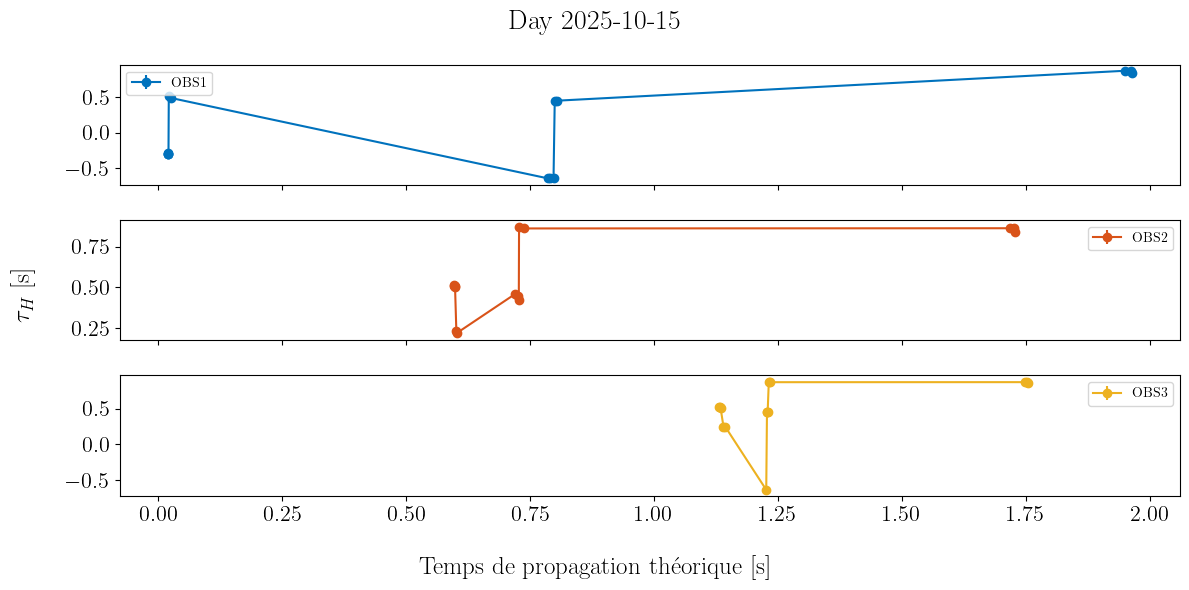

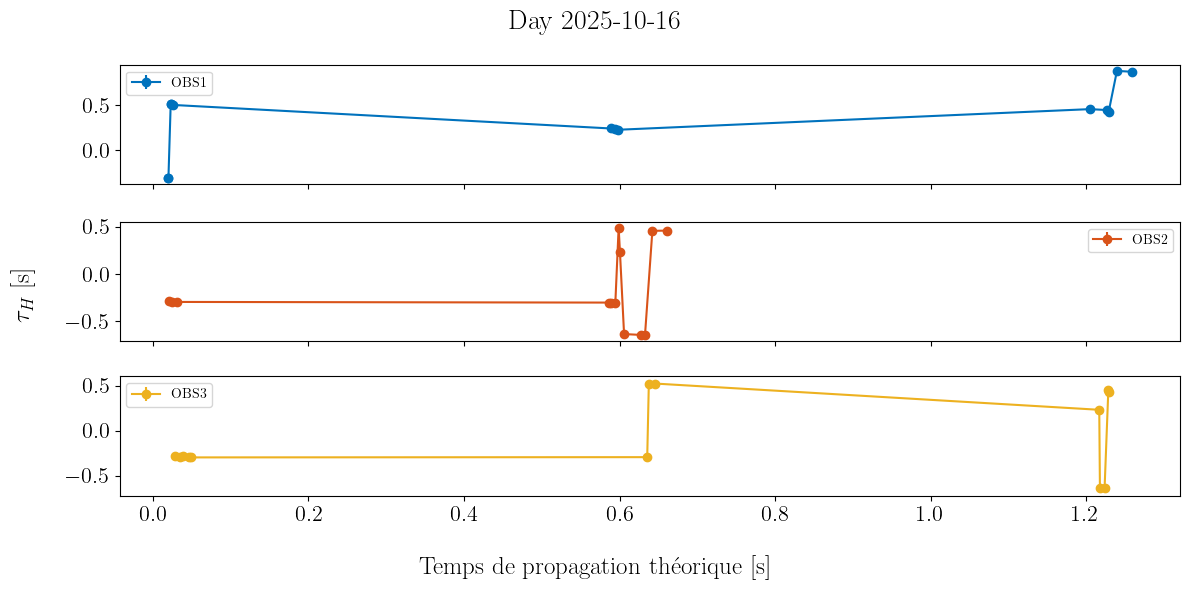

In [15]:
for day_idx, day in enumerate(days):
    # ax = axs[day_idx] if days.size > 1 else axs
    fig, axs = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
    day_mask_1 = np.array([d.date() == day for d in sequence_datetimes_obs1])
    day_mask_2 = np.array([d.date() == day for d in sequence_datetimes_obs2])
    day_mask_3 = np.array([d.date() == day for d in sequence_datetimes_obs3])

    axs[0].errorbar(
        obs1_th_propagation_times[day_mask_1],
        np.array(obs1_mean_time_offsets)[day_mask_1],
        yerr=3 * np.array(obs1_std_time_offsets)[day_mask_1],
        fmt="o-",
        label="OBS1",
        color=color(0),
    )
    axs[1].errorbar(
        obs2_th_propagation_times[day_mask_2],
        np.array(obs2_mean_time_offsets)[day_mask_2],
        yerr=3 * np.array(obs2_std_time_offsets)[day_mask_2],
        fmt="o-",
        label="OBS2",
        color=color(1),
    )
    axs[2].errorbar(
        obs3_th_propagation_times[day_mask_3],
        np.array(obs3_mean_time_offsets)[day_mask_3],
        yerr=3 * np.array(obs3_std_time_offsets)[day_mask_3],
        fmt="o-",
        label="OBS3",
        color=color(2),
    )
    fig.suptitle(f"Day {day}")
    fig.supxlabel("Temps de propagation théorique [s]")
    fig.supylabel(r"$\tau_{H}$ [s]")
    axs[0].legend()
    axs[1].legend()
    axs[2].legend()

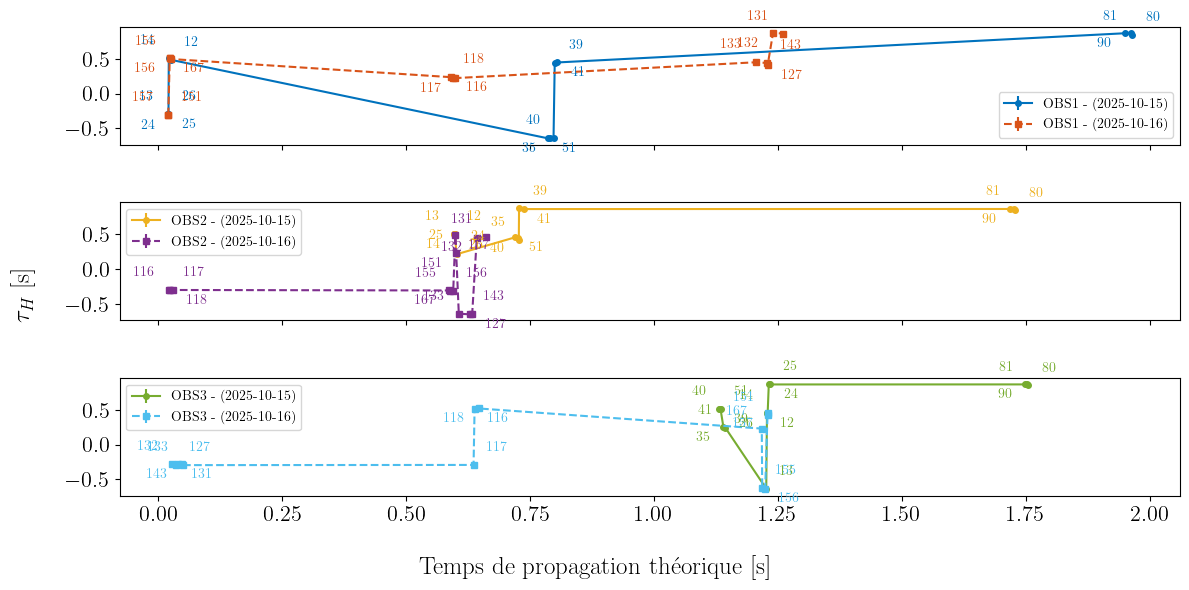

In [16]:
fig, axs = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
formats = ["o-", "s--", "x:"]
for day_idx, day in enumerate(days):
    # ax = axs[day_idx] if days.size > 1 else axs
    day_mask_1 = np.array([d.date() == day for d in sequence_datetimes_obs1])
    day_mask_2 = np.array([d.date() == day for d in sequence_datetimes_obs2])
    day_mask_3 = np.array([d.date() == day for d in sequence_datetimes_obs3])

    axs[0].errorbar(
        obs1_th_propagation_times[day_mask_1],
        np.array(obs1_mean_time_offsets)[day_mask_1],
        yerr=3 * np.array(obs1_std_time_offsets)[day_mask_1],
        fmt=formats[day_idx],
        label=f"OBS1 - ({day})",
        color=color(0 + day_idx),
        markersize=4,
    )

    axs[1].errorbar(
        obs2_th_propagation_times[day_mask_2],
        np.array(obs2_mean_time_offsets)[day_mask_2],
        yerr=3 * np.array(obs2_std_time_offsets)[day_mask_2],
        fmt=formats[day_idx],
        label=f"OBS2 - ({day})",
        color=color(2 + day_idx),
        markersize=4,
    )
    axs[2].errorbar(
        obs3_th_propagation_times[day_mask_3],
        np.array(obs3_mean_time_offsets)[day_mask_3],
        yerr=3 * np.array(obs3_std_time_offsets)[day_mask_3],
        fmt=formats[day_idx],
        label=f"OBS3 - ({day})",
        color=color(4 + day_idx),
        markersize=4,
    )

    # Annotate each data point with the corresponding sequence id
    sel_sequence_id_obs1_day = np.array(sel_sequence_id_obs1)[day_mask_1]
    sel_sequence_id_obs2_day = np.array(sel_sequence_id_obs2)[day_mask_2]
    sel_sequence_id_obs3_day = np.array(sel_sequence_id_obs3)[day_mask_3]
    day_masks = [day_mask_1, day_mask_2, day_mask_3]
    for i_obs in [1, 2, 3]:
        if i_obs == 1:
            sel_sequence_id_obs = sel_sequence_id_obs1_day
            th_propa_obs = obs1_th_propagation_times
            time_offset_obs = obs1_mean_time_offsets 
        elif i_obs == 2:
            sel_sequence_id_obs = sel_sequence_id_obs2_day
            th_propa_obs = obs2_th_propagation_times
            time_offset_obs = obs2_mean_time_offsets
        else:
            sel_sequence_id_obs = sel_sequence_id_obs3_day
            th_propa_obs = obs3_th_propagation_times
            time_offset_obs = obs3_mean_time_offsets

        j_lab = 0
        for i, seq_id in enumerate(sel_sequence_id_obs):
            # print(
            #     f"OBS{i_obs} - Annotating sequence {seq_id} -> th_propa: {th_propa_obs[day_mask][i]}"
            # )
            # Alternate the position of the labels to avoid overlap
            ha = "right" if j_lab % 4 in [0, 3] else "left"
            x_offset = -10 if j_lab % 4 in [0, 3] else 10
            y_offset = 10 if j_lab % 4 in [0, 1] else -10
            axs[i_obs - 1].annotate(
                seq_id,
                (
                    th_propa_obs[day_masks[i_obs - 1]][i],
                    np.array(time_offset_obs)[day_masks[i_obs - 1]][i],
                ),
                textcoords="offset points",
                xytext=(x_offset, y_offset),
                ha=ha,
                fontsize=10,
                color=color((i_obs - 1) * 2 + day_idx),
                fontweight="bold",
            )
            j_lab += 1

# fig.suptitle(f"Day {day}")
fig.supxlabel("Temps de propagation théorique [s]")
fig.supylabel(r"$\tau_{H}$ [s]")
axs[0].legend()
axs[1].legend()
axs[2].legend()
# axs[0].set_xscale("log")

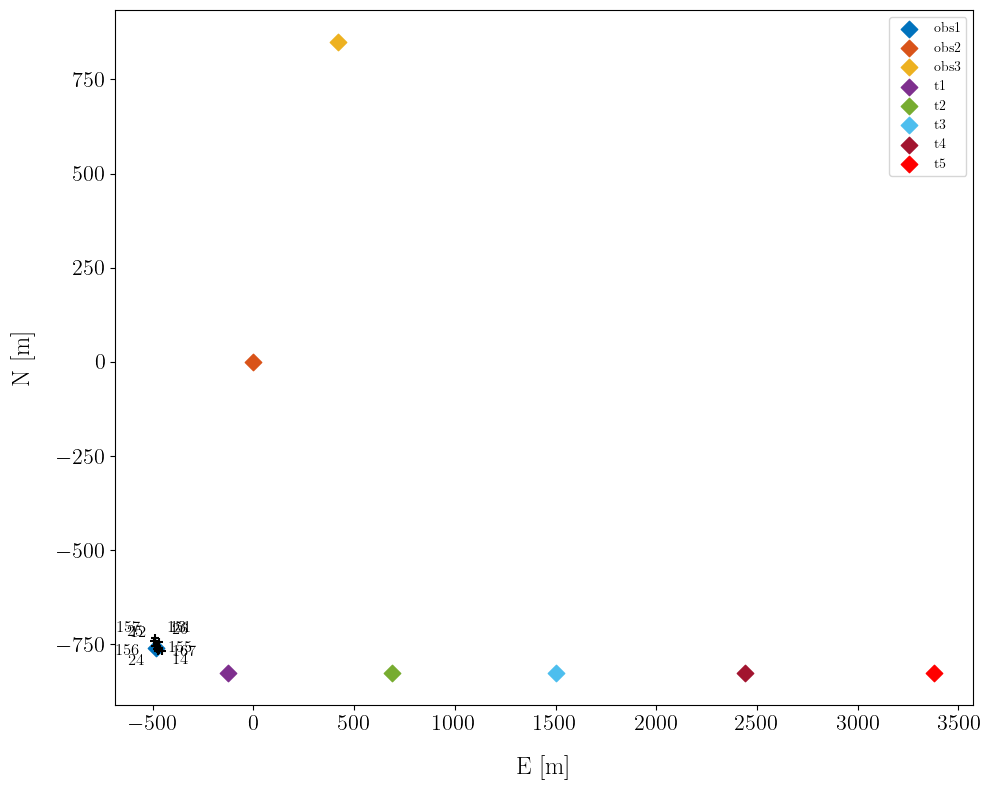

In [17]:
# Tracer des positions d'émission et des positions des OBS sur une carte
sel_sequence_id_to_analyse = [seq_id for seq_id in [12, 13, 14, 24, 25, 26, 155, 156, 157, 151, 167]]
# Plot
plt.figure(figsize=(10, 8))
for i, seq_id in enumerate(sel_sequence_id_to_analyse):
    df_sequence = df_processed.loc[df_processed["sequence_id"] == seq_id]
    # print(f"Sequence {seq_id}:")
    # print(df_sequence.head(2))
    # Get propagation time for OBS1
    # time_diff[seq_id]["Theoretical propagation time OBS1"]
    # print(f"Sequence {seq_id}: theoretical propagation time OBS1 = {df_sequence['Theoretical propagation time OBS1']} s")


    plt.scatter(
        df_sequence["emission_interp_e_gps"].iloc[0],
        df_sequence["emission_interp_n_gps"].iloc[0],
        marker="+",
        color="k",
        # "s",
        # label="Sequence emission pos",
    )
    # Annotate with sequence id
    # Alternate the position of the labels to avoid overlap
    ha = "right" if i % 4 in [0, 3] else "left"
    x_offset = -10 if i % 4 in [0, 3] else 10
    y_offset = 10 if i % 4 in [0, 1] else -10
    plt.annotate(
        seq_id,
        (
            df_sequence["emission_interp_e_gps"].iloc[0],
            df_sequence["emission_interp_n_gps"].iloc[0],
        ),
        textcoords="offset points",
        xytext=(x_offset, y_offset),
        ha=ha,
        fontsize=12,
    )


plt.xlabel("E [m]")
plt.ylabel("N [m]")

keys = ["obs1", "obs2", "obs3", "t1", "t2", "t3", "t4", "t5"]
for ik, k in enumerate(keys):
    e = ds_gps.attrs[f"{k}_e_apriori"]
    n = ds_gps.attrs[f"{k}_n_apriori"]
    plt.scatter(
        e,
        n,
        marker="D",
        label=k,
        zorder=0,
        color=color(ik),
        s=70,
    )


plt.legend()

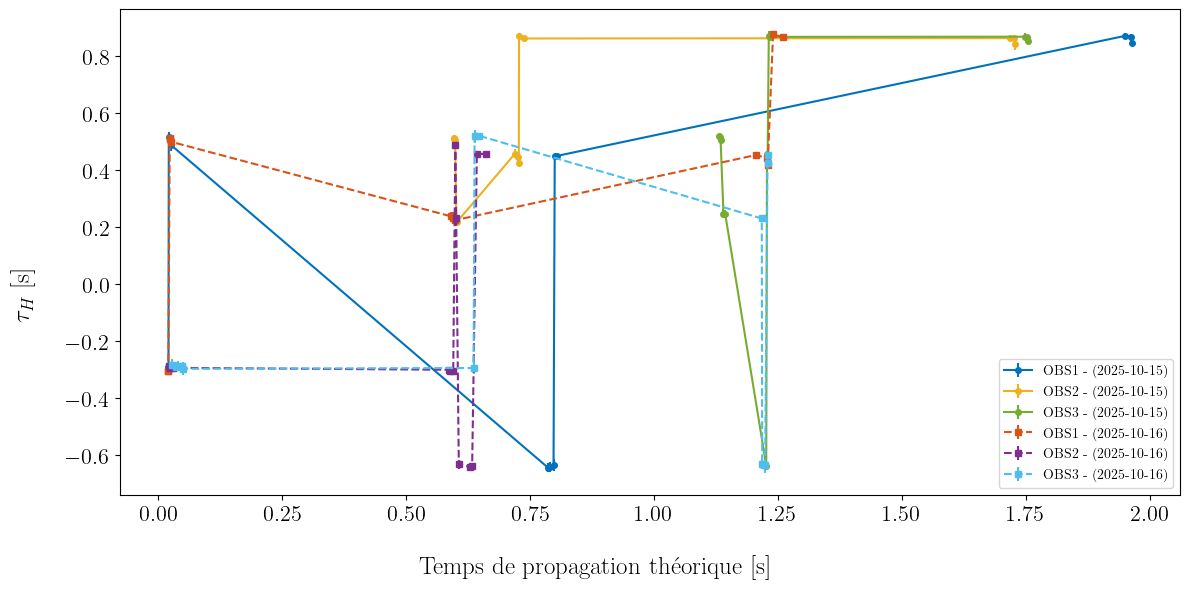

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6), sharex=True)
formats = ["o-", "s--", "x:"]
for day_idx, day in enumerate(days):
    # ax = axs[day_idx] if days.size > 1 else axs
    day_mask_1 = np.array([d.date() == day for d in sequence_datetimes_obs1])
    day_mask_2 = np.array([d.date() == day for d in sequence_datetimes_obs2])
    day_mask_3 = np.array([d.date() == day for d in sequence_datetimes_obs3])

    ax.errorbar(
        obs1_th_propagation_times[day_mask_1],
        np.array(obs1_mean_time_offsets)[day_mask_1],
        yerr=3 * np.array(obs1_std_time_offsets)[day_mask_1],
        fmt=formats[day_idx],
        label=f"OBS1 - ({day})",
        color=color(0 + day_idx),
        markersize=4,
    )

    ax.errorbar(
        obs2_th_propagation_times[day_mask_2],
        np.array(obs2_mean_time_offsets)[day_mask_2],
        yerr=3 * np.array(obs2_std_time_offsets)[day_mask_2],
        fmt=formats[day_idx],
        label=f"OBS2 - ({day})",
        color=color(2 + day_idx),
        markersize=4,
    )
    ax.errorbar(
        obs3_th_propagation_times[day_mask_3],
        np.array(obs3_mean_time_offsets)[day_mask_3],
        yerr=3 * np.array(obs3_std_time_offsets)[day_mask_3],
        fmt=formats[day_idx],
        label=f"OBS3 - ({day})",
        color=color(4 + day_idx),
        markersize=4,
    )

# fig.suptitle(f"Day {day}")
fig.supxlabel("Temps de propagation théorique [s]")
fig.supylabel(r"$\tau_{H}$ [s]")
ax.legend()

### Commentaires

À des séquences émises depuis la même position, mais à des instants différents correspondent des shifts mesurés très différents (par exemple pour les émissions depuis le point 1). 

Il n'y a priori pas de corrélation évidente entre position de la source et shift mesuré. La variation du shift mesuré ne résulte donc a priori pas d'erreurs d'estimation dues aux incertitudes de positionnement de la source et des OBS.  

# Conclusions

En l'état, il n'est pas possible de recaler les temps d'émissions sur le temps UTC des OBS à partir de la mesure des temps d'arrivée. 

Il faut utiliser les logs Fosina pour connaitre les instants d'émission. 